In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns if needed
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("/Users/akashkumarsamantray/Desktop/amz_uk_price_prediction_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2443651, 9)


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [6]:
## Missing Values
df.isnull().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [7]:
## Category Columns
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [8]:
# Number of unique categories
print("Unique Categories:", df['category'].nunique())



Unique Categories: 296


In [9]:
# Sample categories
df['category'].unique()[:10]

array(['Hi-Fi Speakers', 'CD, Disc & Tape Players', 'Wearable Technology',
       'Light Bulbs', 'Bathroom Lighting',
       'Heating, Cooling & Air Quality', 'Coffee & Espresso Machines',
       'Lab & Scientific Products', 'Smart Speakers',
       'Motorbike Clothing'], dtype=object)

In [11]:
## Frequency table
category_table = pd.DataFrame({
    'Category': category_freq.index,
    'Frequency': category_freq.values
})

category_table.head(10)

,Category,Frequency
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978
5,Manicure & Pedicure Products,18940
6,Skin Care,18769
7,Make-up,18756
8,Hair Care,18735
9,Fragrances,18564


In [12]:
## Top 5 Most Listed Categories
top_5_categories = df['category'].value_counts().head(5)

print(top_5_categories)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


In [ ]:
## Bar Chart for top 10 categories

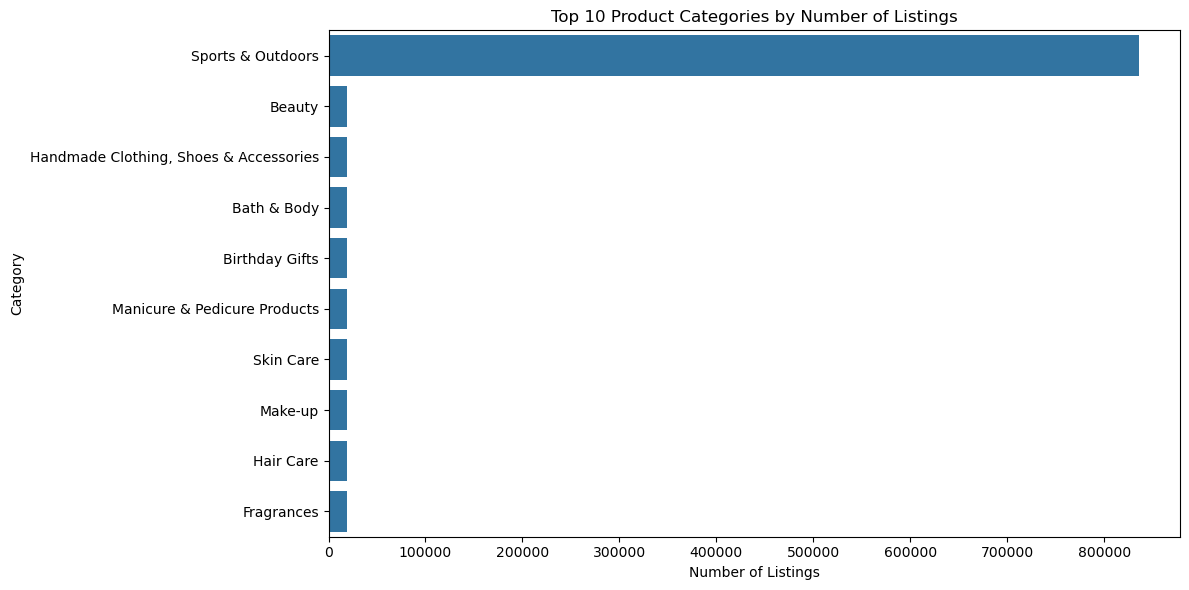

In [13]:
# Top 10 categories
top_10_categories = df['category'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_10_categories.values,
    y=top_10_categories.index
)

plt.title('Top 10 Product Categories by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [ ]:
## Pie chart for top 5 categoeies

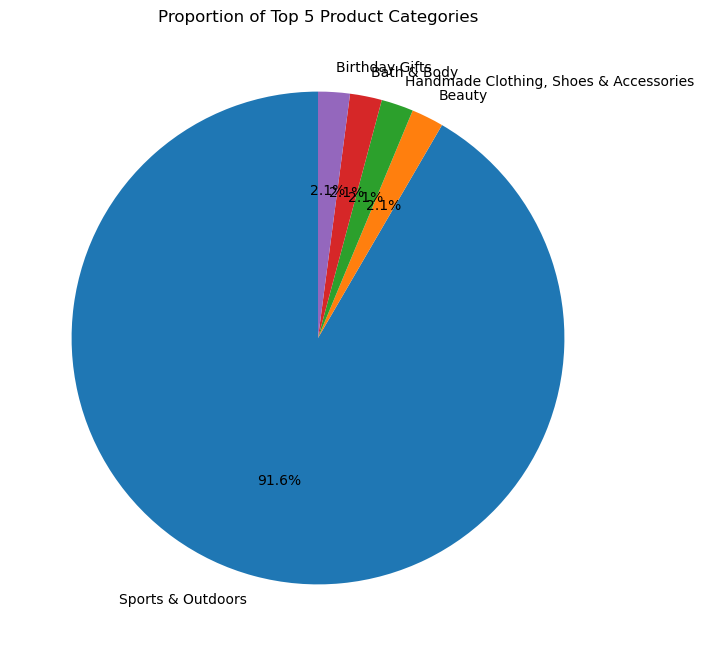

In [14]:
# Top 5 categories
top_5_categories = df['category'].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.pie(
    top_5_categories.values,
    labels=top_5_categories.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proportion of Top 5 Product Categories')
plt.show()

In [ ]:
## Percentage

In [15]:
top_5_percentage = (
    df['category']
    .value_counts(normalize=True)
    .head(5) * 100
)

print(top_5_percentage)

category
Sports & Outdoors                         34.221949
Beauty                                     0.790293
Handmade Clothing, Shoes & Accessories     0.786896
Bath & Body                                0.781290
Birthday Gifts                             0.776625
Name: proportion, dtype: float64


In [ ]:
## Frequency Table Analysis

In [ ]:
The frequency analysis shows that Sports & Outdoors is the most common product category on Amazon UK, with 836,265 listings. 
    The next four categories—Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body, and Birthday Gifts—each contain approximately 19,000 listings. 
    This indicates a highly uneven distribution of products across categories.

In [ ]:
## Bar Chart Analysis

In [ ]:
The bar chart clearly demonstrates that the Sports & Outdoors category has substantially more listings than any other category. 
The difference is so large that the remaining categories appear comparatively small, suggesting a strong concentration of products in this category.

In [ ]:
## Pie Chart Analysis

In [ ]:
The pie chart confirms that Sports & Outdoors dominates the listings among the top five categories. 
Its share is significantly larger than the other categories, which contribute relatively small proportions of the total listings.
Therefore, the Amazon UK product catalogue in this dataset is heavily concentrated in the Sports & Outdoors category.

In [ ]:
## Business Insight

In [ ]:
Product availability is highly concentrated in the Sports & Outdoors segment, indicating either strong seller participation or broad product diversity within this category. 
    Categories such as Beauty and Bath & Body are important but represent a much smaller portion of the overall catalogue.

In [ ]:
## Part 2: Delving into Product Pricing

In [16]:
## Inspecting the Price Column
# Check data type and basic info
df['price'].describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [17]:
print("Missing values:", df['price'].isnull().sum())

Missing values: 0


In [18]:
## Calculate Mean, Median, and Mode

# Mean
price_mean = df['price'].mean()

# Median
price_median = df['price'].median()

# Mode
price_mode = df['price'].mode()[0]

print("Mean Price:", round(price_mean, 2))
print("Median Price:", round(price_median, 2))
print("Mode Price:", price_mode)

Mean Price: 89.24
Median Price: 19.09
Mode Price: 9.99


In [19]:
## Created a summary table
centrality_table = pd.DataFrame({
    'Measure': ['Mean', 'Median', 'Mode'],
    'Value': [price_mean, price_median, price_mode]
})

centrality_table

,Measure,Value
0,Mean,89.243809
1,Median,19.090000
2,Mode,9.990000


In [20]:
## Compare mean vs median
print(f"Mean Price: £{price_mean:.2f}")
print(f"Median Price: £{price_median:.2f}")
print(f"Mode Price: £{price_mode:.2f}")

Mean Price: £89.24
Median Price: £19.09
Mode Price: £9.99


In [ ]:
## Measures of Centrality Analysis
The average (mean) product price is £89.24, while the median price is £19.09 and the most common price (mode) is £9.99.
The mean is higher than the median, suggesting that the price distribution is right-skewed due to the presence of expensive products.
The mode indicates that £9.99 is the most frequently occurring product price in the dataset.    


In [ ]:
## Business Insight
Most products are concentrated around the median price point, while a smaller number of very expensive products influence the average price. 
Therefore, the median provides a more representative measure of a typical product price than the mean.

In [ ]:
## Measure and Dispersion

In [21]:
## Calculate Variance and Standard Deviation

# Variance
price_variance = df['price'].var()

# Standard Deviation
price_std = df['price'].std()

print("Variance:", round(price_variance, 2))
print("Standard Deviation:", round(price_std, 2))

Variance: 119445.49
Standard Deviation: 345.61


In [22]:
## Calculate Range

price_min = df['price'].min()
price_max = df['price'].max()

price_range = price_max - price_min

print("Minimum Price:", price_min)
print("Maximum Price:", price_max)
print("Range:", price_range)

Minimum Price: 0.0
Maximum Price: 100000.0
Range: 100000.0


In [23]:
## Calculate Interquartile Range (IQR)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 9.99
Q3: 45.99
IQR: 36.0


In [ ]:
## Summary Table

In [24]:
dispersion_table = pd.DataFrame({
    'Measure': ['Variance', 'Standard Deviation', 'Range', 'IQR'],
    'Value': [price_variance, price_std, price_range, IQR]
})

dispersion_table

,Measure,Value
0,Variance,119445.485323
1,Standard Deviation,345.608862
2,Range,100000.000000
3,IQR,36.000000


In [ ]:
## Interpretation

In [ ]:
The variance of 119,445.49 and the standard deviation of £345.61 indicate a substantial spread in product prices. 
The standard deviation is particularly large compared to typical Amazon product prices, suggesting that some products are priced 
far away from the average.

In [ ]:
The minimum price is £0.00, while the maximum price reaches £100,000.00, resulting in an extremely large range of £100,000.00. 
This indicates the presence of extreme values or outliers in the dataset.

In [ ]:
The first quartile (Q1) is £9.99 and the third quartile (Q3) is £45.99, producing an interquartile range (IQR) of £36.00. 
This means that the middle 50% of products are priced within a relatively narrow range between approximately £10 and £46.

In [ ]:
## Business Insight

In [ ]:
Although most Amazon UK products are priced within a moderate range, a small number of extremely expensive products significantly increase the overall spread of the data. 
The fact that the IQR (£36) is tiny compared to the total range (£100,000) strongly suggests the presence of substantial outliers. 
Therefore, median and IQR are likely more representative measures of the typical product price than the mean and range.

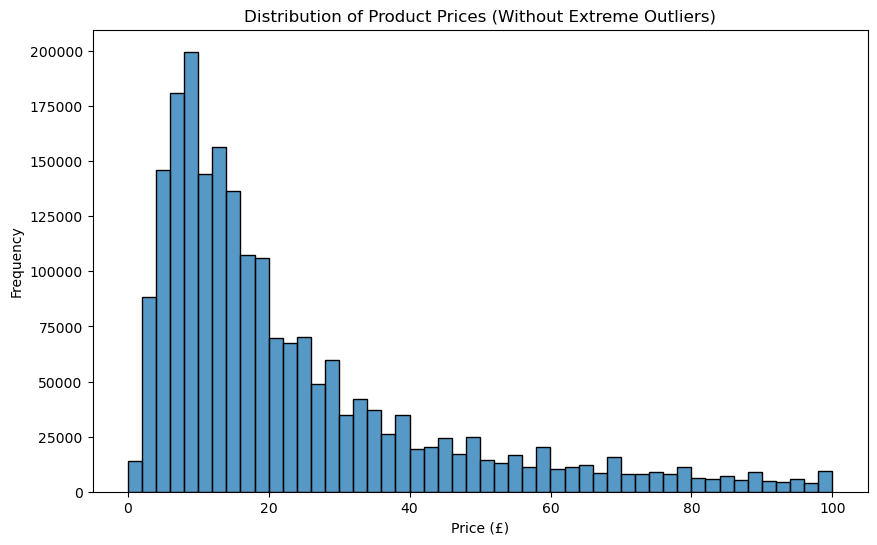

In [26]:
## Histogram
# Upper bound using IQR rule
upper_bound = Q3 + 1.5 * IQR

filtered_prices = df[df['price'] <= upper_bound]

plt.figure(figsize=(10,6))

sns.histplot(filtered_prices['price'], bins=50)

plt.title('Distribution of Product Prices (Without Extreme Outliers)')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')
plt.show()

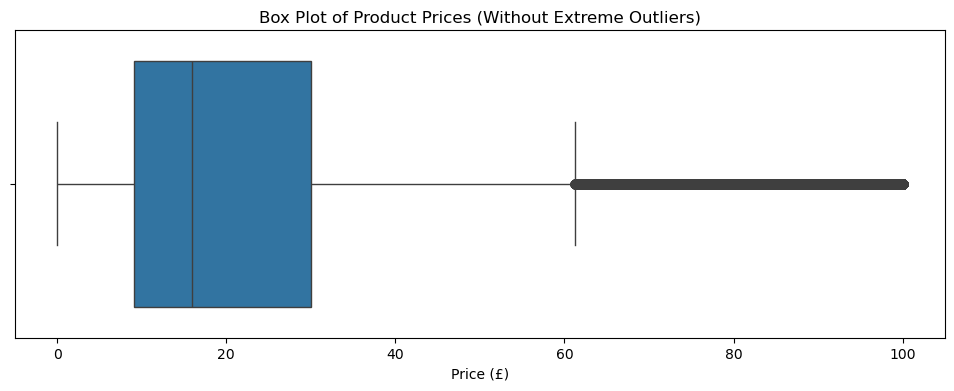

In [27]:
## Box Plot
plt.figure(figsize=(12,4))

sns.boxplot(x=filtered_prices['price'])

plt.title('Box Plot of Product Prices (Without Extreme Outliers)')
plt.xlabel('Price (£)')
plt.show()

In [ ]:
## Part 3: Unpacking Product Ratings

In [ ]:
## Checking rating column

In [29]:
# Basic information about ratings
df['stars'].describe()

count    2.443651e+06
mean     2.152836e+00
std      2.194865e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.400000e+00
max      5.000000e+00
Name: stars, dtype: float64

In [31]:
# Check missing values
print("Missing values:", df['stars'].isnull().sum())

Missing values: 0


In [ ]:
## Calculate Mean, Median, and Mode

In [33]:
rating_mean = df['stars'].mean()
rating_median = df['stars'].median()
rating_mode = df['stars'].mode()[0]

print("Mean Rating:", round(rating_mean, 2))
print("Median Rating:", rating_median)
print("Mode Rating:", rating_mode)

Mean Rating: 2.15
Median Rating: 0.0
Mode Rating: 0.0


In [ ]:
## Summary Table

In [34]:
rating_centrality = pd.DataFrame({
    'Measure': ['Mean', 'Median', 'Mode'],
    'Value': [rating_mean, rating_median, rating_mode]
})

rating_centrality

,Measure,Value
0,Mean,2.152836
1,Median,0.000000
2,Mode,0.000000


In [ ]:
## Calculate Variance and Standard Deviation

In [36]:
rating_variance = df['stars'].var()
rating_std = df['stars'].std()

print("Variance:", round(rating_variance, 4))
print("Standard Deviation:", round(rating_std, 4))

Variance: 4.8174
Standard Deviation: 2.1949


In [ ]:
## Calculate Interquartile Range (IQR)

In [37]:
Q1_rating = df['stars'].quantile(0.25)
Q3_rating = df['stars'].quantile(0.75)

IQR_rating = Q3_rating - Q1_rating

print("Q1:", Q1_rating)
print("Q3:", Q3_rating)
print("IQR:", IQR_rating)

Q1: 0.0
Q3: 4.4
IQR: 4.4


In [ ]:
## Summary Table

In [38]:
rating_dispersion = pd.DataFrame({
    'Measure': ['Variance', 'Standard Deviation', 'IQR'],
    'Value': [rating_variance, rating_std, IQR_rating]
})

rating_dispersion

,Measure,Value
0,Variance,4.817434
1,Standard Deviation,2.194865
2,IQR,4.400000


In [ ]:
## Shape of the Distribution:

In [ ]:
## Calculate Skewness and Kurtosis

In [40]:
# Skewness
rating_skewness = df['stars'].skew()

# Kurtosis
rating_kurtosis = df['stars'].kurt()

print("Skewness:", round(rating_skewness, 4))
print("Kurtosis:", round(rating_kurtosis, 4))

Skewness: 0.0812
Kurtosis: -1.926


In [ ]:
## Visualize the Distribution

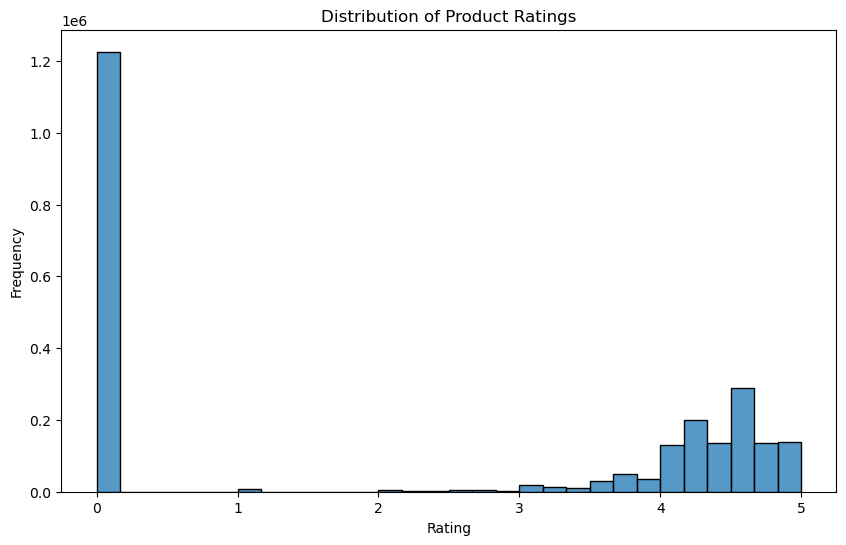

In [41]:
plt.figure(figsize=(10,6))

sns.histplot(df['stars'], bins=30)

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [ ]:
## Visualizations:

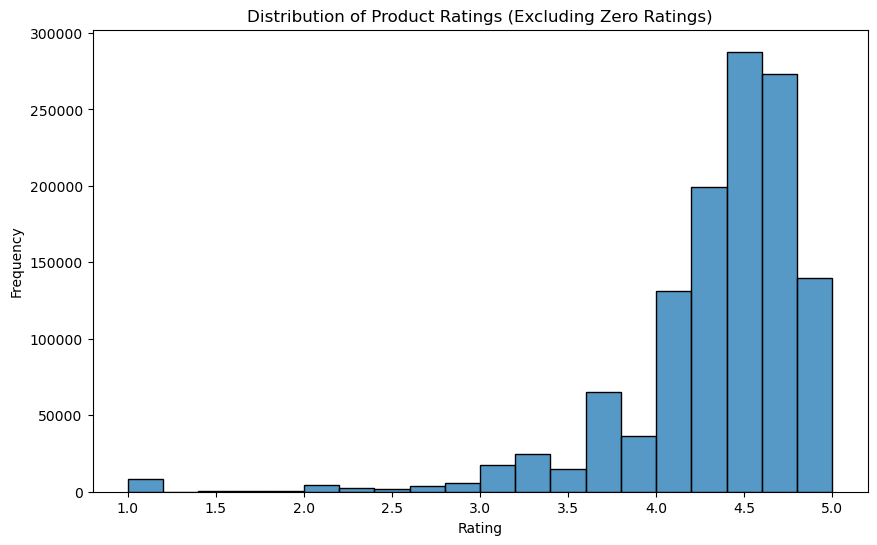

In [43]:
rated_products = df[df['stars'] > 0]

plt.figure(figsize=(10,6))

sns.histplot(rated_products['stars'], bins=20)

plt.title('Distribution of Product Ratings (Excluding Zero Ratings)')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()